# ¿Qué hace el `FactorPersona`?

**EOD Santiago 2012** — explicación para la tarea

---

La encuesta no encuestó a *todos* los santiaguinos. Encuestó a una **muestra**: ~28 000 personas de ~8 000 hogares seleccionados. Cada persona encuestada **representa** a un número de personas reales en la población.

Ese número es el `FactorPersona`.

**Interpretación directa:**
> Si a una persona le corresponde `FactorPersona = 100`, esa fila del dataset representa a 100 personas reales con características similares en Santiago.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

RUTA = "datos/external/eod_stgo"

pts = gpd.read_file(f"{RUTA}/origenes_viajes.gpkg")

# Una fila por persona (cada persona aparece varias veces en pts, una por viaje)
personas = pts.drop_duplicates("Persona")
print(f"Personas únicas: {len(personas):,}")

Personas únicas: 27,622


## 1. ¿Cómo se ve el factor?

Miramos la distribución del `FactorPersona` en la muestra.

In [2]:
personas["FactorPersona"].describe().round(1)

count    27622.0
mean       118.9
std        203.3
min          0.5
25%         31.7
50%         57.7
75%        120.2
max       3112.5
Name: FactorPersona, dtype: float64

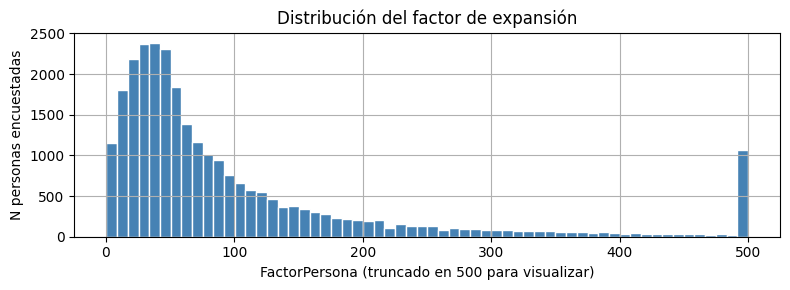

Factor mínimo : 0.5
Factor mediano: 57.7
Factor máximo : 3112.5


In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
personas["FactorPersona"].clip(upper=500).hist(bins=60, ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("FactorPersona (truncado en 500 para visualizar)")
ax.set_ylabel("N personas encuestadas")
ax.set_title("Distribución del factor de expansión")
plt.tight_layout()
plt.show()

print(f"Factor mínimo : {personas['FactorPersona'].min():.1f}")
print(f"Factor mediano: {personas['FactorPersona'].median():.1f}")
print(f"Factor máximo : {personas['FactorPersona'].max():.1f}")

El factor varía mucho entre personas. Eso no es un error: refleja que en algunos estratos socioeconómicos o zonas de la ciudad se encuestó a **menos** hogares relativamente, y cada uno de esos hogares encuestados carga con un peso mayor.

---

## 2. El problema: ingreso medio sin factor

Supongamos que queremos calcular el ingreso medio de los habitantes de una zona EOD. La forma más intuitiva sería:

In [4]:
# Filtramos personas con ingreso declarado > 0 y educación válida
p = personas[(personas["IngresoFinal"] > 0) & (personas["Estudios"] < 90)].copy()

# Zona de ejemplo: la 407 (tiene datos suficientes)
zona_ejemplo = p[p["Zona"] == 407].copy()
print(f"Personas encuestadas en zona 407: {len(zona_ejemplo)}")
zona_ejemplo[["Persona", "FactorPersona", "IngresoFinal"]].head(10)

Personas encuestadas en zona 407: 73


,Persona,FactorPersona,IngresoFinal
2,17343101,46.32137,339356
5,17344101,46.32137,350000
7,17344103,43.02566,283883
27503,17342102,67.77744,230000
28077,17530202,35.53664,246466
28350,17606101,375.07507,400000
28464,17624101,49.44887,69599
28466,17624102,81.55230,284844
28821,17715302,270.76758,309894
28840,17720101,33.08601,350000


In [5]:
# Ingreso medio SIN factor: cada fila cuenta igual
ingreso_sin_factor = zona_ejemplo["IngresoFinal"].mean()

# Ingreso medio CON factor: cada fila pesa según cuántas personas reales representa
w  = zona_ejemplo["FactorPersona"]
ingreso_con_factor = (zona_ejemplo["IngresoFinal"] * w).sum() / w.sum()

print(f"Ingreso medio SIN factor: ${ingreso_sin_factor:,.0f}")
print(f"Ingreso medio CON factor: ${ingreso_con_factor:,.0f}")
print(f"Diferencia: ${abs(ingreso_con_factor - ingreso_sin_factor):,.0f}  ({(ingreso_con_factor/ingreso_sin_factor - 1)*100:+.1f}%)")

Ingreso medio SIN factor: $312,250
Ingreso medio CON factor: $301,937
Diferencia: $10,314  (-3.3%)


## 3. ¿Por qué difieren?

La diferencia ocurre porque **las personas con factor alto y con factor bajo no tienen el mismo ingreso**. Si las personas de mayor factor (más "invisibles" en la muestra) son sistemáticamente más pobres o más ricas, ignorar el factor sesga el promedio.

Lo podemos ver directamente:

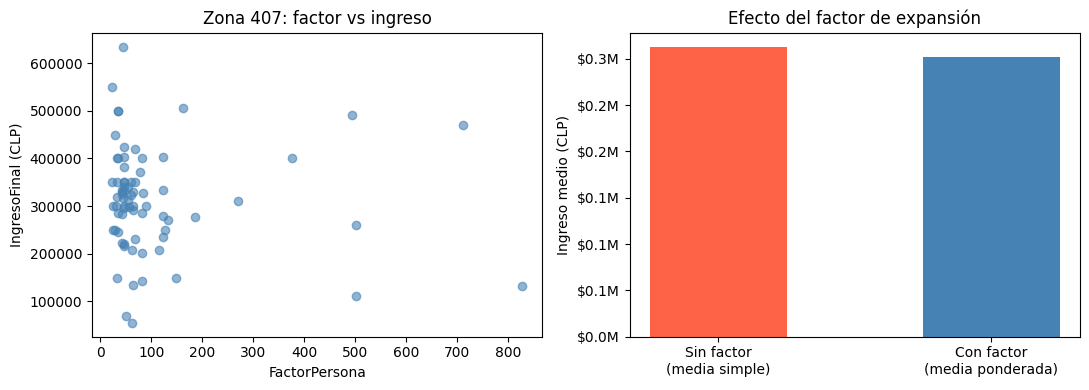

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Scatter: factor vs ingreso
axes[0].scatter(zona_ejemplo["FactorPersona"], zona_ejemplo["IngresoFinal"],
                alpha=0.6, color="steelblue")
axes[0].set_xlabel("FactorPersona")
axes[0].set_ylabel("IngresoFinal (CLP)")
axes[0].set_title("Zona 407: factor vs ingreso")

# Barras de comparación
axes[1].bar(["Sin factor\n(media simple)", "Con factor\n(media ponderada)"],
            [ingreso_sin_factor, ingreso_con_factor],
            color=["tomato", "steelblue"], width=0.5)
axes[1].set_ylabel("Ingreso medio (CLP)")
axes[1].set_title("Efecto del factor de expansión")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

plt.tight_layout()
plt.show()

## 4. La fórmula general

Para cualquier variable $x$ en un grupo de personas:

$$\bar{x}_{\text{ponderado}} = \frac{\sum_i w_i \cdot x_i}{\sum_i w_i}$$

donde $w_i$ = `FactorPersona` de la persona $i$.

En Python eso es exactamente lo que hace la función de la tarea:

In [7]:
def agregar_personas(df):
    w  = df["FactorPersona"].fillna(1.0)   # si falta el factor, asumir 1 (la persona se representa a sí misma)
    ws = w.sum()                            # suma de factores = N de personas reales en la zona
    return pd.Series({
        "n_personas":    len(df),
        "ingreso_medio": (df["IngresoFinal"] * w).sum() / ws,
        "pct_educ_sup":  ((df["Estudios"] >= 9) * w).sum() / ws * 100,
        "edad_media":    ((2012 - df["AnoNac"]) * w).sum() / ws,
    })

La lógica es la misma para las tres variables:

| Variable | Lo que se multiplica por $w_i$ |
|---|---|
| `ingreso_medio` | el ingreso de cada persona |
| `pct_educ_sup` | 1 si tiene educación superior, 0 si no |
| `edad_media` | `2012 - AnoNac` (edad aproximada en el año de la encuesta) |

## 5. ¿Cuánto importa a escala de toda la ciudad?

Calculamos el ingreso medio por zona con y sin factor para todas las zonas y comparamos.

In [8]:
p_validos = personas[(personas["IngresoFinal"] > 0) & (personas["Estudios"] < 90)].copy()

# Sin factor
sin = p_validos.groupby("Zona")["IngresoFinal"].mean().rename("sin_factor")

# Con factor
con = p_validos.groupby("Zona").apply(
    lambda d: (d["IngresoFinal"] * d["FactorPersona"]).sum() / d["FactorPersona"].sum(),
    include_groups=False
).rename("con_factor")

comp = pd.concat([sin, con], axis=1).dropna()
comp["diferencia_pct"] = (comp["con_factor"] / comp["sin_factor"] - 1) * 100

print(f"Zonas con datos: {len(comp)}")
print()
print("Diferencia % entre media ponderada y simple:")
comp["diferencia_pct"].describe().round(1)

Zonas con datos: 762

Diferencia % entre media ponderada y simple:


count    762.0
mean       3.8
std       18.0
min      -41.9
25%       -5.1
50%        1.4
75%       10.7
max      156.0
Name: diferencia_pct, dtype: float64

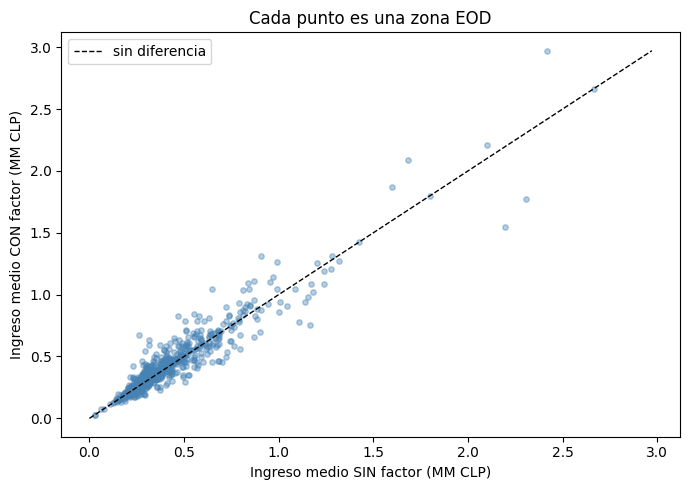

Zonas donde la diferencia supera el 20%: 148


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(comp["sin_factor"] / 1e6, comp["con_factor"] / 1e6,
           alpha=0.4, s=15, color="steelblue")
lim = max(comp[["sin_factor","con_factor"]].max()) / 1e6
ax.plot([0, lim], [0, lim], "k--", lw=1, label="sin diferencia")
ax.set_xlabel("Ingreso medio SIN factor (MM CLP)")
ax.set_ylabel("Ingreso medio CON factor (MM CLP)")
ax.set_title("Cada punto es una zona EOD")
ax.legend()
plt.tight_layout()
plt.show()

print("Zonas donde la diferencia supera el 20%:",
      (comp["diferencia_pct"].abs() > 20).sum())

## Resumen

| | Sin `FactorPersona` | Con `FactorPersona` |
|---|---|---|
| ¿Qué representa cada fila? | una persona encuestada | una persona encuestada **que representa a $w_i$ personas reales** |
| ¿Cuándo da lo mismo? | cuando el factor es igual para todos | casi nunca en encuestas reales |
| ¿Qué sesgamos al ignorarlo? | sobrerepresentamos estratos donde se encuestó más | nada: la estimación es insesgada |

**Regla práctica:** en cualquier encuesta con factor de expansión, siempre usar la media ponderada. La suma `w.sum()` en el denominador hace que el resultado sea interpretable como la media poblacional de la zona.